# Advanced Feature Engineering
```
cls_feat = outputs.last_hidden_state[:, 0, :]
mean_feat = outputs.last_hidden_state[:, 1:, :].mean(dim=1)
max_feat = outputs.last_hidden_state[:, 1:, :].max(dim=1)[0]
```

### Imports

In [1]:
!pip install /kaggle/input/pip-show-protobuf/protobuf-3.20.3-py2.py3-none-any.whl

Processing /kaggle/input/pip-show-protobuf/protobuf-3.20.3-py2.py3-none-any.whl
  Attempting uninstall: protobuf
    Found existing installation: protobuf 6.33.0
    Uninstalling protobuf-6.33.0:
      Successfully uninstalled protobuf-6.33.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigframes 2.12.0 requires google-cloud-bigquery-storage<3.0.0,>=2.30.0, which is not installed.
opentelemetry-proto 1.37.0 requires protobuf<7.0,>=5.0, but you have protobuf 3.20.3 which is incompatible.
onnx 1.18.0 requires protobuf>=4.25.1, but you have protobuf 3.20.3 which is incompatible.
a2a-sdk 0.3.10 requires protobuf>=5.29.5, but you have protobuf 3.20.3 which is incompatible.
ray 2.51.1 requires click!=8.3.0,>=7.0, but you have click 8.3.0 which is incompatible.
bigframes 2.12.0 requires rich<14,>=12.4.4, but you have rich 14.2.0 which is incompatible.
tensorflow-me

In [2]:
import os
import re
import glob
import time

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image
from tqdm import tqdm

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split


import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import torchvision
import torchvision.transforms as transforms
from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, Subset, Dataset

from transformers import AutoImageProcessor, AutoModel

2025-12-09 23:11:54.657926: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1765321914.855183      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1765321914.911245      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
img_dir_path = "/kaggle/input/csiro-biomass"

In [4]:
print("Read csv data")
d_train = pd.read_csv("/kaggle/input/csiro-biomass/train.csv", parse_dates=["Sampling_Date"])
d_test = pd.read_csv("/kaggle/input/csiro-biomass/test.csv")
print("Done")

Read csv data
Done


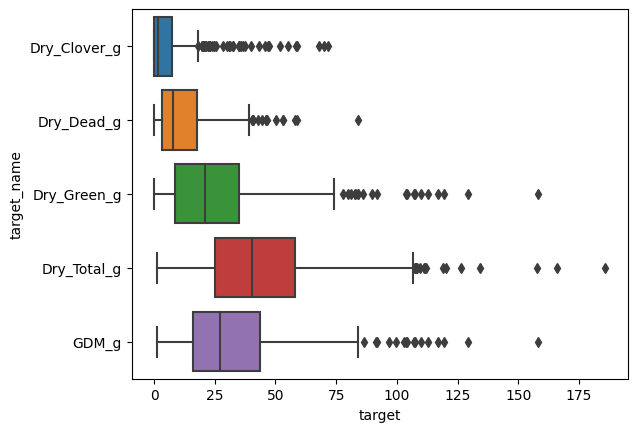

In [5]:
sns.boxplot(d_train, x='target', y='target_name')
plt.show()

In [6]:
d_img_metrics = d_train.groupby(by=['image_path', 'Species'], as_index=False)[['Pre_GSHH_NDVI', 'Height_Ave_cm']].max()

<Axes: xlabel='Pre_GSHH_NDVI', ylabel='Species'>

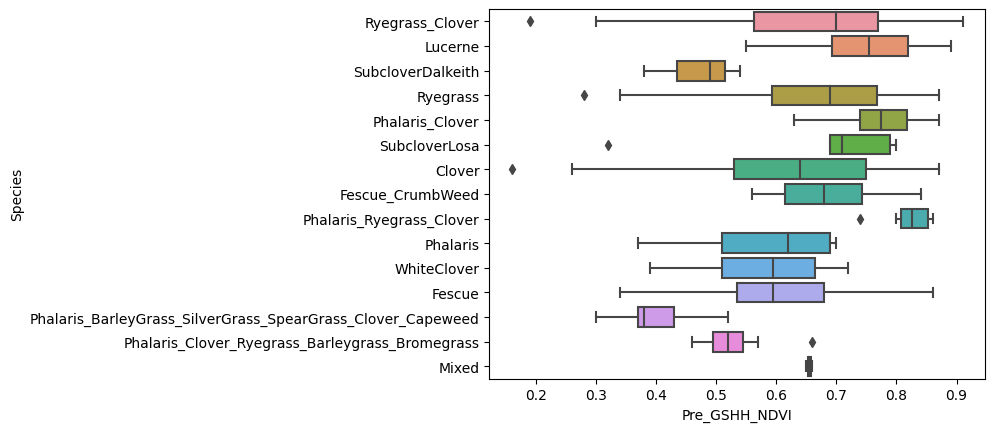

In [7]:
sns.boxplot(d_img_metrics, x='Pre_GSHH_NDVI', y='Species')

In [8]:
d_train.target_name.unique()

array(['Dry_Clover_g', 'Dry_Dead_g', 'Dry_Green_g', 'Dry_Total_g',
       'GDM_g'], dtype=object)

/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


<Axes: xlabel='target', ylabel='Count'>

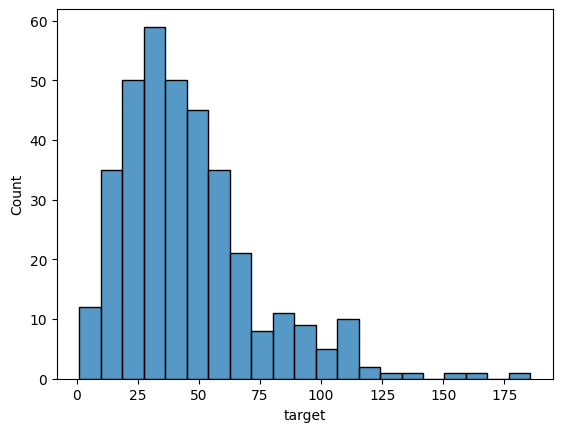

In [9]:
sns.histplot(d_train.loc[d_train.target_name == 'Dry_Total_g', 'target'])

In [10]:
d_temp = d_train.pivot(index='image_path', columns='target_name', values='target').reset_index()

In [11]:
d_temp.head()

target_name,image_path,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
0,train/ID1011485656.jpg,0.0000,31.9984,16.2751,48.2735,16.2750
1,train/ID1012260530.jpg,0.0000,0.0000,7.6000,7.6000,7.6000
2,train/ID1025234388.jpg,6.0500,0.0000,0.0000,6.0500,6.0500
3,train/ID1028611175.jpg,0.0000,30.9703,24.2376,55.2079,24.2376
4,train/ID1035947949.jpg,0.4343,23.2239,10.5261,34.1844,10.9605


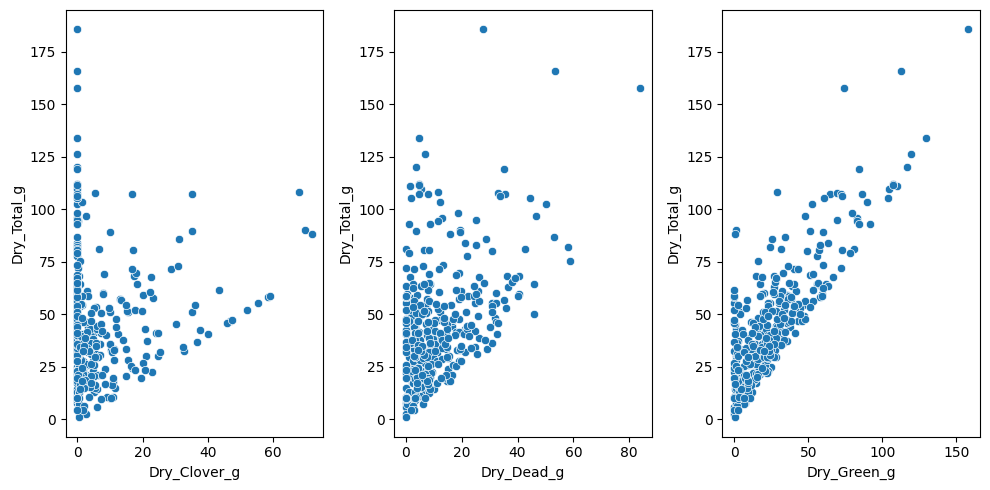

In [12]:
fig, ax = plt.subplots(1, 3, figsize=(10, 5))
sns.scatterplot(d_temp, x='Dry_Clover_g', y='Dry_Total_g', ax=ax[0])
sns.scatterplot(d_temp, x='Dry_Dead_g', y='Dry_Total_g', ax=ax[1])
sns.scatterplot(d_temp, x='Dry_Green_g', y='Dry_Total_g', ax=ax[2])
plt.tight_layout()

<Axes: xlabel='target_name', ylabel='target_name'>

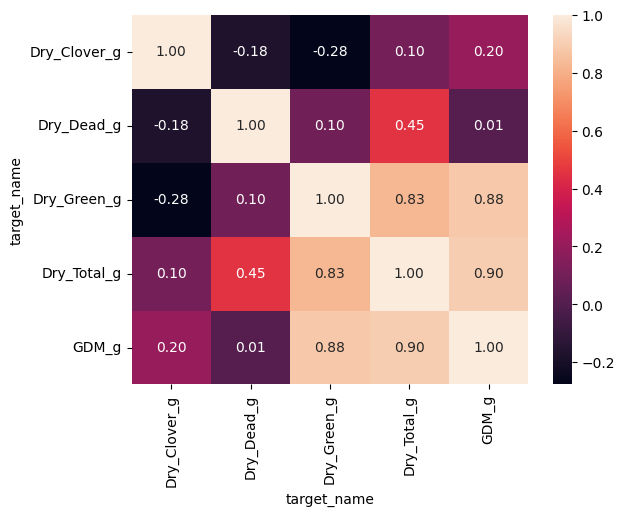

In [13]:
sns.heatmap(d_temp.iloc[:, 1:].corr(), annot=True, fmt='.2f')

### Load DINOv2 backbone

In [14]:
print("Load dinov2 model")
# processor = AutoImageProcessor.from_pretrained('facebook/dinov2-giant')
processor = AutoImageProcessor.from_pretrained('/kaggle/input/dinov2/pytorch/giant/1')
model = AutoModel.from_pretrained('/kaggle/input/dinov2/pytorch/giant/1')
print("Done")

Using a slow image processor as `use_fast` is unset and a slow processor was saved with this model. `use_fast=True` will be the default behavior in v4.52, even if the model was saved with a slow processor. This will result in minor differences in outputs. You'll still be able to use a slow processor with `use_fast=False`.


Load dinov2 model


/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'repr' attribute with value False was provided to the `Field()` function, which has no effect in the context it was used. 'repr' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` statement was used, or if the `Field()` function was attached to a single member of a union type.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/pydantic/_internal/_generate_schema.py:2249: UnsupportedFieldAttributeWarning: The 'frozen' attribute with value True was provided to the `Field()` function, which has no effect in the context it was used. 'frozen' is field-specific metadata, and can only be attached to a model field using `Annotated` metadata or by assignment. This may have happened because an `Annotated` type alias using the `type` 

Done


In [15]:
model = model.cuda()

In [16]:
model = model.eval()

#### Get embedding from DINOv2

In [17]:
def extract_embedding_from_model(img_path):
    img_full_path = os.path.join(img_dir_path, img_path)
    img = Image.open(img_full_path)
    
    inputs = processor(images=img, return_tensors="pt")
    inputs = inputs.to('cuda')
    
    with torch.no_grad():
        outputs = model(**inputs)
    
    cls_feat = outputs.last_hidden_state[:, 0, :]
    mean_feat = outputs.last_hidden_state[:, 1:, :].mean(dim=1)
    max_feat = outputs.last_hidden_state[:, 1:, :].max(dim=1)[0]
    
    return torch.cat([cls_feat, mean_feat, max_feat], dim=1).squeeze(0)

In [18]:
start = time.time()
data_img_embed = {}
for path in tqdm(d_train.image_path.unique()):
    img_embedding = extract_embedding_from_model(path)
    data_img_embed[path] = img_embedding
    break

duration = time.time() - start
print(f"Get image embedding duration: {duration:.2f}s")

  0%|          | 0/357 [00:00<?, ?it/s]

Get image embedding duration: 0.81s


In [19]:
img_emb_size = img_embedding.cpu().numpy().shape[0]
print(f"Img Emb size: {img_emb_size}")

Img Emb size: 4608


### Prepare Dataset

In [20]:
d_train_pivot = d_train.pivot(index='image_path', columns='target_name', values='target').reset_index()
d_train_pivot.columns.name = None

In [21]:
train, valid = train_test_split(d_train_pivot, test_size=0.2, random_state=123)
train.shape, valid.shape

((285, 6), (72, 6))

In [22]:
def apply_ss(train, valid):
    
    ss_map = {}
    for col in train.columns[1:]:
        ss_map[col] = StandardScaler()
        target_train_scaled = ss_map[col].fit_transform(train[col].to_numpy().reshape(-1, 1))
        valid_train_scaled = ss_map[col].transform(valid[col].to_numpy().reshape(-1, 1))
        train[col] = target_train_scaled
        valid[col] = valid_train_scaled

    return train, valid

In [23]:
def apply_log_transform(train, valid):
    train.iloc[:, 1:] = train.iloc[:, 1:].apply(np.log1p)
    valid.iloc[:, 1:] = valid.iloc[:, 1:].apply(np.log1p)

    return train, valid

In [24]:
# train, valid = apply_log_transform(train, valid)

In [25]:
train.head()

,image_path,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
236,train/ID384648061.jpg,0.0000,27.7164,157.9836,185.7000,157.9836
327,train/ID8209776.jpg,9.9586,14.1080,12.0333,36.1000,21.9920
102,train/ID1509266870.jpg,2.7750,2.7750,27.7500,33.3000,30.5250
331,train/ID846984946.jpg,8.4000,8.0000,0.6000,17.0000,9.0000
196,train/ID2048645043.jpg,4.1860,11.5116,10.4651,26.1628,14.6512


In [26]:
valid.head()

,image_path,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
218,train/ID249042826.jpg,10.6616,3.8769,1.8000,16.3385,12.4615
48,train/ID1237349078.jpg,3.1890,26.2210,9.3900,38.8000,12.5790
11,train/ID1058383417.jpg,0.1000,9.5000,13.1000,22.7000,13.2000
114,train/ID1563418511.jpg,0.0000,4.5904,107.1096,111.7000,107.1096
41,train/ID1193692654.jpg,0.2727,6.3317,13.4232,20.0276,13.6959


In [27]:
id2target = dict((idx, col) for idx, col in enumerate(train.columns[1:]))
target2id = dict((col, idx) for idx, col in enumerate(train.columns[1:]))

In [28]:
class CSIRO(Dataset):
    def __init__(self, train, valid):
        self.split = {
            'train': (train, len(train)),
            'valid': (valid, len(valid))
        }

        self.set_split(split="train")

    def set_split(self, split='train'):
        self.data, self.length = self.split[split]

    def __getitem__(self, idx):
        img_path = self.data.iloc[idx, 0]
        x = extract_embedding_from_model(img_path)
         
        y = np.array(self.data.iloc[idx, 1:].tolist())

        return x, y

    def __len__(self):
        return self.length

In [29]:
dataset = CSIRO(train, valid)
data_gen = DataLoader(dataset, batch_size = 2)
x, y = next(iter(data_gen))
x = x.cuda()
y = y.cuda()
print("x.shape and y.shape after data loader", x.shape, y.shape)

x.shape and y.shape after data loader torch.Size([2, 4608]) torch.Size([2, 5])


### Regressor

In [30]:
class MLP(nn.Module):
    def __init__(self, emb_size):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(emb_size, 512),
            nn.LeakyReLU(),
            nn.Linear(512, 128),
            nn.LeakyReLU(),
            nn.Linear(128, 5),
            nn.ReLU(),
        )

    def forward(self, input_x):
        out = self.model(input_x)

        return out

In [31]:
print("Create MLP model...")
model_regressor = MLP(img_emb_size)
model_regressor = model_regressor.cuda()

total_params = sum(param.numel() for param in model_regressor.parameters())
print(f"Total regressor params: {total_params:,}")
print("Done")

Create MLP model...
Total regressor params: 2,426,117
Done


### Loss Function

In [32]:
class WeightedMSELoss(nn.Module):
    def __init__(self):
        super(WeightedMSELoss, self).__init__()
        # Competition weights
        self.weights = torch.tensor([0.1, 0.1, 0.1, 0.5, 0.2])  # [Dry_Clover, Dry_Dead, Dry_Green, Dry_Total, GDM]
    
    def forward(self, pred, target):
        # pred, target shape: [batch_size, 5]
        mse = (pred - target) ** 2
        weighted_mse = mse * self.weights.to(pred.device)
        
        return weighted_mse.mean()

In [33]:
class WeightedHuberLoss(nn.Module):
    def __init__(self, delta=30):
        super().__init__()
        self.delta = delta
        self.weights = torch.tensor([0.1, 0.1, 0.1, 0.5, 0.2]).cuda() # [Dry_Clover, Dry_Dead, Dry_Green, Dry_Total, GDM]
        
    def forward(self, pred, target):
        error = pred - target
        is_small = torch.abs(error) <= self.delta
        small_loss = 0.5 * error ** 2
        large_loss = self.delta * torch.abs(error) - 0.5 * self.delta ** 2
        
        # Weight by target magnitude
        loss = torch.where(is_small, small_loss, large_loss)
        weighted_loss = loss * self.weights
        
        return weighted_loss.mean()

In [34]:
def compute_weighted_r2(pred, target):
    weights = torch.Tensor([0.1, 0.1, 0.1, 0.5, 0.2]).cuda()
    
    # Compute weighted R²
    weighted_mean = (weights * target).mean()
    ss_res = torch.sum(weights * (target - pred)**2)
    ss_tot = torch.sum(weights * (target - weighted_mean)**2)
    return 1 - (ss_res / ss_tot)

### Training routine

In [35]:
print("Define optimizer and loss function...")
optimizer = optim.AdamW(model_regressor.parameters(), lr=0.001)
criterion = WeightedHuberLoss(delta=30)
print(f"Optimizer: {optimizer.__class__.__name__}")
print(f"Loss function: {criterion.__class__.__name__}")
print("Done")

Define optimizer and loss function...
Optimizer: AdamW
Loss function: WeightedHuberLoss
Done


In [36]:
for epoch in range(1, 101):
    start = time.time()

    train_loss = 0
    valid_loss = 0
    train_r2 = 0
    valid_r2 = 0
    
    dataset.set_split("train")
    data_gen = DataLoader(dataset, batch_size=512, shuffle=False)
    model_regressor.train()
    for batch_index, (x, y) in enumerate(data_gen, 1):
        x = x.cuda()
        y = y.cuda()
        
        model_regressor.zero_grad()

        out = model_regressor(x)
        loss = criterion(out, y)
        
        train_loss += (loss.item() - train_loss) / batch_index

        r2 = compute_weighted_r2(out, y)
        train_r2 += (r2 - train_r2) / batch_index

        loss.backward()
        optimizer.step()

    dataset.set_split("valid")
    data_gen = DataLoader(dataset, batch_size=512, shuffle=False)
    model_regressor.eval()
    for batch_index, (x, y) in enumerate(data_gen, 1):
        x = x.cuda()
        y = y.cuda()
        
        with torch.no_grad():
            out = model_regressor(x)

        loss = criterion(out, y)

        valid_loss += (loss.item() - valid_loss) / batch_index

        r2 = compute_weighted_r2(out, y)
        valid_r2 += (r2 - valid_r2) / batch_index

    duration = int(time.time() - start)
    print(f"Epoch: {epoch} | Time: {duration}s")
    print(f"\t Train loss: {train_loss} | R2: {train_r2}")
    print(f"\t Valid loss: {valid_loss} | R2: {valid_r2}")

Epoch: 1 | Time: 52s
	 Train loss: 132.67343156938242 | R2: -0.26782990257128314
	 Valid loss: 98.26844309606871 | R2: 0.04444900071203817
Epoch: 2 | Time: 51s
	 Train loss: 103.40681407951786 | R2: 0.04265390380799139
	 Valid loss: 69.0362073245484 | R2: 0.3369614143295403
Epoch: 3 | Time: 51s
	 Train loss: 71.69982712589999 | R2: 0.3577931389195509
	 Valid loss: 66.05214881298217 | R2: 0.4308145815441615
Epoch: 4 | Time: 51s
	 Train loss: 64.13693991571782 | R2: 0.4759055961267723
	 Valid loss: 75.94847212876827 | R2: 0.38583387561723914
Epoch: 5 | Time: 51s
	 Train loss: 71.05619654778208 | R2: 0.442074360809554
	 Valid loss: 70.19267499570529 | R2: 0.436854025066166
Epoch: 6 | Time: 51s
	 Train loss: 65.42694124192963 | R2: 0.49206087487178496
	 Valid loss: 58.98873663261455 | R2: 0.5112829255237652
Epoch: 7 | Time: 51s
	 Train loss: 55.83533642321068 | R2: 0.5594289468036306
	 Valid loss: 52.95691984125388 | R2: 0.5340653025473423
Epoch: 8 | Time: 51s
	 Train loss: 51.640790508166

### Sanity Check

In [37]:
start = time.time()
result_inference = []
model_regressor.eval()
for path in train.head(5).image_path.unique():

    embedding = extract_embedding_from_model(path)

    with torch.no_grad():
        y_pred = model_regressor(embedding)

    clover, dead, green, total, gdm = y_pred
    
    result_inference.append({
        'image_path': path, 
        'Dry_Clover_g': clover.item(), 
        'Dry_Dead_g': dead.item(), 
        'Dry_Green_g': green.item(), 
        'Dry_Total_g': total.item(), 
        'GDM_g': gdm.item()
    })
    
duration = time.time() - start
print(f"Regressor duration on test: {duration:.2f}s")

Regressor duration on test: 1.08s


In [38]:
d_train_sc = pd.DataFrame(result_inference)

In [39]:
pd.concat((train.set_index('image_path'), d_train_sc.set_index('image_path')), axis=1, join='inner')

,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g,Dry_Clover_g,Dry_Dead_g,Dry_Green_g,Dry_Total_g,GDM_g
image_path,,,,,,,,,,
train/ID384648061.jpg,0.0000,27.7164,157.9836,185.7000,157.9836,0.000000,20.738367,67.720306,126.587349,109.288940
train/ID8209776.jpg,9.9586,14.1080,12.0333,36.1000,21.9920,0.343802,5.672865,27.185781,28.737324,23.295618
train/ID1509266870.jpg,2.7750,2.7750,27.7500,33.3000,30.5250,0.000000,6.655947,26.582321,31.484413,24.726511
train/ID846984946.jpg,8.4000,8.0000,0.6000,17.0000,9.0000,2.404227,6.354666,20.872885,18.725927,12.718170
train/ID2048645043.jpg,4.1860,11.5116,10.4651,26.1628,14.6512,0.000000,9.182496,30.002670,32.770111,23.089922


### Submission

In [40]:
d_test.head()

,sample_id,image_path,target_name
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g


In [41]:
d_test.shape

(5, 3)

In [42]:
start = time.time()
result_inference = []
model_regressor.eval()
for path in d_test.image_path.unique():

    embedding = extract_embedding_from_model(path)

    with torch.no_grad():
        y_pred = model_regressor(embedding)

    clover, dead, green, total, gdm = y_pred
    
    result_inference.append({
        'image_path': path, 
        'Dry_Clover_g': clover.item(), 
        'Dry_Dead_g': dead.item(), 
        'Dry_Green_g': green.item(), 
        'Dry_Total_g': total.item(), 
        'GDM_g': gdm.item()
    })
duration = time.time() - start
print(f"Regressor duration on test: {duration:.2f}s")

Regressor duration on test: 0.24s


In [43]:
d_test_pred_raw = pd.DataFrame(result_inference)
target_names = list(target2id.keys())
d_test_pred = d_test_pred_raw.melt(id_vars='image_path', value_vars=target_names)
d_test_pred = d_test_pred.rename({'variable': 'target_name', 'value': 'target'}, axis=1)

In [44]:
d_test_pred.head()

,image_path,target_name,target
0,test/ID1001187975.jpg,Dry_Clover_g,0.000000
1,test/ID1001187975.jpg,Dry_Dead_g,19.836637
2,test/ID1001187975.jpg,Dry_Green_g,41.868706
3,test/ID1001187975.jpg,Dry_Total_g,57.044342
4,test/ID1001187975.jpg,GDM_g,34.137543


In [45]:
d_submission = pd.merge(left=d_test, right=d_test_pred, how='left', on=['image_path', 'target_name'])
d_submission[['sample_id', 'target']].to_csv('submission.csv', index=False)
d_submission

,sample_id,image_path,target_name,target
0,ID1001187975__Dry_Clover_g,test/ID1001187975.jpg,Dry_Clover_g,0.000000
1,ID1001187975__Dry_Dead_g,test/ID1001187975.jpg,Dry_Dead_g,19.836637
2,ID1001187975__Dry_Green_g,test/ID1001187975.jpg,Dry_Green_g,41.868706
3,ID1001187975__Dry_Total_g,test/ID1001187975.jpg,Dry_Total_g,57.044342
4,ID1001187975__GDM_g,test/ID1001187975.jpg,GDM_g,34.137543
